# ROC Curve Comparison at Peak vs Sub-Peak Sigma1

**Goal:** Understand what drives the non-monotonic d' bump at ISI=1.

Approach:
1. Fix sigma0 = 10, sweep sigma1 on a fine grid
2. Identify the peak (best d') and one sigma1 step just below it
3. Build the full ROC curve from raw hit/FA scores at both sigma1 values
4. Overlay the two ROC curves with arrows showing how each
   (FPR, TPR) point shifts — revealing whether the bump is driven by
   hits increasing, FAs decreasing, or both.

In [1]:
import sys, os, yaml, torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
from scipy.spatial.distance import pdist
from scipy.stats import norm

sys.path.append('/om2/user/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.utils import path

from utls.plotting import ensure_dir
from utls.loading import (
    load_results_with_exclusion_2,
    move_sequences_to_used,
    load_results_with_exclusion_no_dropping,
)
from utls.runners_v2 import run_experiment_scores, make_noise_schedule
from utls.runners_utils import *
from utls.analysis_helpers import auroc_to_dprime
from utls.io_utils import (
    make_model_save_dir,
    save_all_figures,
    save_single_figure,
    save_runs_summary,
)
from encoders import *

from utls.toy_experiments import (
    make_toy_experiment_list,
    make_compact_multi_isi_sequences,
    infer_trial_isis,
    make_high_diversity_sequences
)
from utls.sigma_fitting import (
    log_mid,
    fit_sigma_1d,
    plot_sigma_fit,
    compute_auroc_sparse,
    compute_auroc_sparse12,
    auc_to_dprime,
)

## 1. Load config & data

In [6]:
def load_config(cfg_path):
    cfg_path = Path(cfg_path)
    if not cfg_path.exists():
        raise FileNotFoundError(cfg_path)
    with open(cfg_path) as f:
        return yaml.safe_load(f), cfg_path


CONFIG_PATH = (
    "/om2/user/bjmedina/auditory-memory/memory/"
    "model_yamls/three-regime/resnet50/nontime_avg/run_000005.yaml"
)

model_cfg, model_cfg_path = load_config(CONFIG_PATH)
print(model_cfg)

{'results_root': '/om2/user/bjmedina/auditory-memory/memory', 'tag': 'slurm', 'experiment': {'is_multi': True, 'n_seqs': 36, 'n_samples': 50, 'which_task': 0}, 'metric': 'cosine', 'noise_model': {'name': 'three-regime', 'sigma0_min': 3.0, 'sigma0_max': 0.5, 'sigma1_min': 0.1, 'sigma1_max': 0.6, 'sigma2_min': 0.0005, 'sigma2_max': 0.1, 't_step': 5}, 'run_id': 'run_000005', 'representation': {'type': 'resnet50', 'layer': 'layer4', 'time_avg': False}}


In [7]:
# ---- experiment ----
exp_cfg = model_cfg["experiment"]
which_task = exp_cfg["which_task"]
is_multi = exp_cfg["is_multi"]
which_isi = exp_cfg.get("which_isi", None)

isis = [0, 1, 2, 4, 8, 16, 32, 64] if is_multi else [0, which_isi]

# ---- metric ----
metric = model_cfg["metric"]

# ---- noise model ----
noise_cfg = model_cfg["noise_model"]
noise_mode = noise_cfg["name"]
t_step = noise_cfg["t_step"]

# ---- representation ----
repr_cfg = model_cfg["representation"]
time_avg = repr_cfg["time_avg"]
encoder_type = repr_cfg["type"]
layer = repr_cfg.get("layer", None)
pc_dims = repr_cfg.get("pc_dims", None)

# ---- load human data ----
exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi, is_multi, old=False)
)

human_curve = compute_human_curve(human_runs, is_multi, which_isi)
print("ISIs:", isis)
print("Human d' curve:", human_curve)
print(f"Total real sequences: {len(exp_list)}")

/om2/user/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


ISIs: [0, 1, 2, 4, 8, 16, 32, 64]
Human d' curve: [3.39668151 2.95399862 2.37504185 2.09154967 1.95146386 1.88087069
 1.73912519 1.57714871]
Total real sequences: 104


## 2. Build encoder & encode stimuli

In [8]:
NN_ENCODERS = {"kell2018", "resnet50"}
encoder_task = (
    "word_speaker_audioset" if encoder_type in NN_ENCODERS else "audioset"
)

encoder_cfg = dict(
    encoder_type=encoder_type,
    model_name=encoder_type,
    task=encoder_task,
    statistics_dict=statistics_set.statistics,
    model_params=model_params,
    pc_dims=pc_dims,
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    time_avg=time_avg,
    device="cuda",
)

if encoder_type in NN_ENCODERS:
    encoder_cfg["layer"] = layer
if encoder_type == "texture":
    encoder_cfg["pc_dims"] = pc_dims

encoder_name = make_encoder_name(encoder_cfg)
print("Encoder name:", encoder_name)

encoder = build_encoder(encoder_cfg)
X = encode_stimuli(encoder, all_files)
X_np = X.detach().cpu().numpy()
print("Encoded shape:", X_np.shape, "  any NaN?", torch.isnan(X).any().item())

Encoder name: resnet50-layer4
LOADING FROM /om2/user/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
=> loading checkpoint '/om2/user/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/om2/user/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)
Encoded shape: (80, 186368)   any NaN? False


## 3. Parameter bounds & stimulus pool

In [9]:
param_bounds = {
    "sigma0": (0.0001, 22),
    "sigma1": (0.0001, 10),
    "sigma2": (0.0001, 5),
}

print("Parameter bounds:")
for k, v in param_bounds.items():
    print(f"  {k}: ({v[0]:.6f}, {v[1]:.6f})")

stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f"\nStimulus pool size: {len(stimulus_pool)}")

Parameter bounds:
  sigma0: (0.000100, 22.000000)
  sigma1: (0.000100, 10.000000)
  sigma2: (0.000100, 5.000000)

Stimulus pool size: 80


## 4. Human d' targets

In [10]:
isi_to_hc_idx = {isi_val: i for i, isi_val in enumerate(isis)}

sigma0_human = {0: float(human_curve[isi_to_hc_idx[0]])}
sigma1_human = {isi: float(human_curve[isi_to_hc_idx[isi]]) for isi in [1, 2, 4]}

print("Stage A targets (sigma0):")
for isi, dp in sigma0_human.items():
    print(f"  ISI {isi}: human d' = {dp:.4f}")

print("\nStage B targets (sigma1):")
for isi, dp in sigma1_human.items():
    print(f"  ISI {isi}: human d' = {dp:.4f}")

sigma2_init = log_mid(*param_bounds["sigma2"])
print(f"\nInitial sigma2 = {sigma2_init:.6f}")

Stage A targets (sigma0):
  ISI 0: human d' = 3.3967

Stage B targets (sigma1):
  ISI 1: human d' = 2.9540
  ISI 2: human d' = 2.3750
  ISI 4: human d' = 2.0915

Initial sigma2 = 0.022361


---
## 5. Generate sequences and sweep sigma1 (fixed sigma0 = 10)

We fix sigma0 = 10 (as suggested), generate compact multi-ISI sequences,
then sweep sigma1 on a fine grid, caching **all raw hit/FA scores**
so we can reconstruct the full ROC curves.

In [37]:
SIGMA0_FIXED = 10.37
SIGMA1_ISIS = [1, 2, 4]
SIGMA1_LENGTH = 60
SIGMA1_MIN_PAIRS = 5
N_SEQS = 15
N_MC = 5

sigma1_exps, sigma1_isi_keys = make_high_diversity_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=SIGMA1_ISIS,
    n_sequences=N_SEQS,
    length=SIGMA1_LENGTH,
    min_pairs_per_isi=SIGMA1_MIN_PAIRS,
    seed=1000,
)

print(f"Generated {len(sigma1_exps)} sequences, {len(sigma1_exps[0])} trials each")
print(f"sigma0 fixed at: {SIGMA0_FIXED}")

# Validate ISI distribution
isi_counts = defaultdict(list)
for seq in sigma1_exps:
    counts = Counter(infer_trial_isis(seq))
    for isi_val in SIGMA1_ISIS:
        isi_counts[isi_val].append(counts.get(isi_val, 0))

print("\nPairs per ISI per sequence (mean +/- std):")
for isi_val in SIGMA1_ISIS:
    vals = isi_counts[isi_val]
    print(f"  ISI {isi_val}: {np.mean(vals):.1f} +/- {np.std(vals):.1f}  "
          f"(min={min(vals)}, max={max(vals)})")

Aggregate ISI usage across all sequences:
  ISI -1: 300
  ISI 1: 218
  ISI 2: 176
  ISI 4: 206
Generated 15 sequences, 60 trials each
sigma0 fixed at: 10.37

Pairs per ISI per sequence (mean +/- std):
  ISI 1: 7.3 +/- 2.1  (min=5, max=10)
  ISI 2: 5.9 +/- 0.9  (min=5, max=8)
  ISI 4: 6.9 +/- 2.0  (min=5, max=10)


In [38]:
# Fine sigma1 grid — 25 points to get good resolution around the peak
SIGMA1_GRID = np.exp(np.linspace(
    np.log(0.6),
    np.log(15),
    20,
))

seq_trial_isis = [infer_trial_isis(seq) for seq in sigma1_exps]

raw_results = []
for gi, sigma1_val in enumerate(SIGMA1_GRID):
    all_hits_by_isi = {isi: [] for isi in SIGMA1_ISIS}
    all_fas = []

    for rep in range(N_MC):
        for si, seq in enumerate(sigma1_exps):
            t_isis = seq_trial_isis[si]
            run_out = run_experiment_scores(
                sigma0=SIGMA0_FIXED, sigma1=sigma1_val, sigma2=sigma2_init,
                t_step=t_step, rate=0, noise_mode=noise_mode,
                metric=metric, X0=X, name_to_idx=name_to_idx,
                experiment_list=[seq], debug=False,
                seed=600_000 + gi * 100_000 + rep * 1000 + si,
            )
            h = np.asarray(run_out["hits"])
            f = np.asarray(run_out["fas"])
            if len(h) != len(t_isis):
                continue
            for isi_val_inner in SIGMA1_ISIS:
                mask = np.array(t_isis) == isi_val_inner
                all_hits_by_isi[isi_val_inner].extend(h[mask].tolist())
            all_fas.extend(f.tolist())

    raw_results.append({
        "sigma1": sigma1_val,
        "hit_scores_by_isi": {isi: np.array(v) for isi, v in all_hits_by_isi.items()},
        "fa_scores": np.array(all_fas),
    })
    print(f"  [{gi+1}/{len(SIGMA1_GRID)}] sigma1={sigma1_val:.4f}: "
          f"{sum(len(v) for v in all_hits_by_isi.values())} hits, "
          f"{len(all_fas)} fas")

print("\nDone — raw scores cached.")

  [1/20] sigma1=0.6000: 1500 hits, 2925 fas
  [2/20] sigma1=0.7108: 1500 hits, 2925 fas
  [3/20] sigma1=0.8420: 1500 hits, 2925 fas
  [4/20] sigma1=0.9974: 1500 hits, 2925 fas
  [5/20] sigma1=1.1816: 1500 hits, 2925 fas
  [6/20] sigma1=1.3997: 1500 hits, 2925 fas
  [7/20] sigma1=1.6581: 1500 hits, 2925 fas
  [8/20] sigma1=1.9642: 1500 hits, 2925 fas
  [9/20] sigma1=2.3268: 1500 hits, 2925 fas
  [10/20] sigma1=2.7563: 1500 hits, 2925 fas
  [11/20] sigma1=3.2652: 1500 hits, 2925 fas
  [12/20] sigma1=3.8680: 1500 hits, 2925 fas
  [13/20] sigma1=4.5821: 1500 hits, 2925 fas
  [14/20] sigma1=5.4280: 1500 hits, 2925 fas
  [15/20] sigma1=6.4300: 1500 hits, 2925 fas
  [16/20] sigma1=7.6171: 1500 hits, 2925 fas
  [17/20] sigma1=9.0233: 1500 hits, 2925 fas
  [18/20] sigma1=10.6891: 1500 hits, 2925 fas
  [19/20] sigma1=12.6624: 1500 hits, 2925 fas
  [20/20] sigma1=15.0000: 1500 hits, 2925 fas

Done — raw scores cached.


---
## 6. Compute d' vs sigma1 and find peak + sub-peak

Compute d' using sklearn AUROC (the method that shows the bump)
so we can study the non-monotonicity directly.

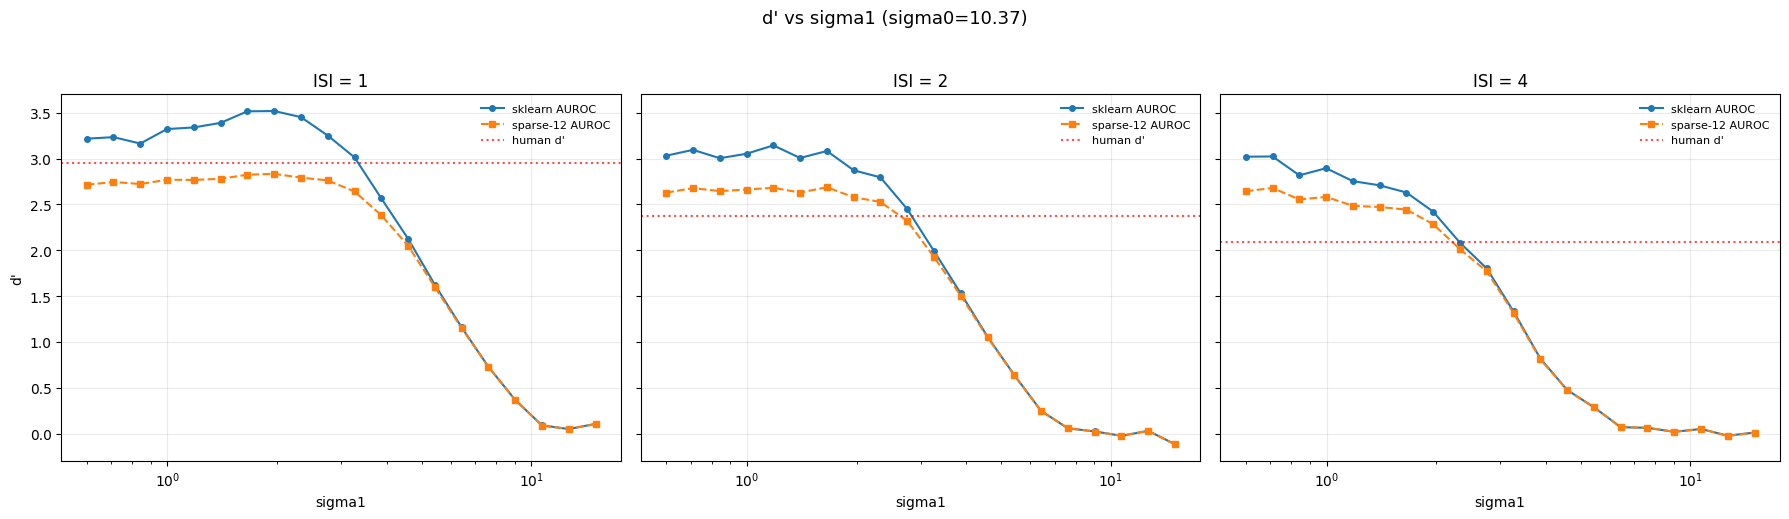

In [39]:
from sklearn.metrics import roc_auc_score

def sklearn_auroc(hits, fas):
    """AUROC via sklearn (lower score = more signal)."""
    hits = np.asarray(hits, dtype=float)
    fas = np.asarray(fas, dtype=float)
    scores = np.concatenate([hits, fas])
    y_true = np.concatenate([np.ones(len(hits)), np.zeros(len(fas))])
    # Lower score = more signal, so we negate
    return roc_auc_score(y_true, -scores)


# Compute d' using both sklearn and sparse12 for comparison
sigma1_vals = np.array([r["sigma1"] for r in raw_results])

dprime_sklearn = {isi: [] for isi in SIGMA1_ISIS}
dprime_sparse12 = {isi: [] for isi in SIGMA1_ISIS}

for r in raw_results:
    for isi_val in SIGMA1_ISIS:
        hits = r["hit_scores_by_isi"][isi_val]
        fas = r["fa_scores"]

        auc_sk = sklearn_auroc(hits, fas)
        dprime_sklearn[isi_val].append(auc_to_dprime(auc_sk, eps=1e-4))

        auc_sp = compute_auroc_sparse12(hits, fas)
        dprime_sparse12[isi_val].append(auc_to_dprime(auc_sp, eps=1e-4))

# Convert to arrays
for isi_val in SIGMA1_ISIS:
    dprime_sklearn[isi_val] = np.array(dprime_sklearn[isi_val])
    dprime_sparse12[isi_val] = np.array(dprime_sparse12[isi_val])

# Plot d' vs sigma1 for ISI=1 to see the bump
fig, axes = plt.subplots(1, len(SIGMA1_ISIS), figsize=(6 * len(SIGMA1_ISIS), 5), sharey=True)
for ax, isi_val in zip(axes, SIGMA1_ISIS):
    ax.plot(sigma1_vals, dprime_sklearn[isi_val], 'o-', ms=4, label='sklearn AUROC', color='tab:blue')
    ax.plot(sigma1_vals, dprime_sparse12[isi_val], 's--', ms=4, label='sparse-12 AUROC', color='tab:orange')
    ax.axhline(sigma1_human[isi_val], ls=':', color='red', alpha=0.7, label="human d'")
    ax.set_xscale('log')
    ax.set_xlabel('sigma1')
    ax.set_title(f'ISI = {isi_val}')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, frameon=False)
axes[0].set_ylabel("d'")
fig.suptitle(f"d' vs sigma1 (sigma0={SIGMA0_FIXED})", y=1.03, fontsize=13)
fig.tight_layout()
plt.show()

In [57]:
# Find peak and sub-peak for ISI=1 using sklearn AUROC (the bumpy one)
isi_focus = 1
dp_isi1 = dprime_sklearn[isi_focus]

peak_idx = np.argmax(dp_isi1)
# Sub-peak: one grid step below the peak (lower sigma1)
sub_peak_idx = peak_idx+3#max(0, peak_idx - 5)

sigma1_peak = sigma1_vals[peak_idx]
sigma1_sub = sigma1_vals[sub_peak_idx]

print(f"ISI={isi_focus} d' curve (sklearn AUROC):")
print(f"  Peak:     sigma1 = {sigma1_peak:.4f}, d' = {dp_isi1[peak_idx]:.4f}  (grid idx {peak_idx})")
print(f"  Sub-peak: sigma1 = {sigma1_sub:.4f}, d' = {dp_isi1[sub_peak_idx]:.4f}  (grid idx {sub_peak_idx})")
print(f"  Delta d': {dp_isi1[peak_idx] - dp_isi1[sub_peak_idx]:.4f}")

ISI=1 d' curve (sklearn AUROC):
  Peak:     sigma1 = 1.9642, d' = 3.5182  (grid idx 7)
  Sub-peak: sigma1 = 3.2652, d' = 3.0128  (grid idx 10)
  Delta d': 0.5055


---
## 7. Build and compare ROC curves

For both the peak and sub-peak sigma1 values, build the full ROC curve
from the raw scores. Then overlay them with arrows showing how each
sampled (FPR, TPR) point shifts.

In [58]:
def build_roc_curve(hits, fas):
    """Build full ROC curve (lower score = more signal).

    Returns (fpr, tpr, thresholds) sorted by FPR.
    """
    hits = np.asarray(hits, dtype=float)
    fas = np.asarray(fas, dtype=float)
    P, N = len(hits), len(fas)

    scores = np.concatenate([hits, fas])
    y_true = np.concatenate([np.ones(P), np.zeros(N)])

    thr = np.unique(np.sort(scores))
    tpr = np.array([(scores[y_true == 1] <= t).sum() / P for t in thr])
    fpr = np.array([(scores[y_true == 0] <= t).sum() / N for t in thr])

    return fpr, tpr, thr


def sample_roc_at_fpr_targets(fpr, tpr, n_points=12):
    """Sample the ROC curve at uniformly-spaced FPR targets.

    Returns (fpr_sampled, tpr_sampled) with (0,0) and (1,1) anchors.
    """
    target_fpr = np.linspace(0, 1, n_points + 2)[1:-1]
    idx = np.unique([np.argmin(np.abs(fpr - f)) for f in target_fpr])
    fpr_s = np.concatenate([[0.0], fpr[idx], [1.0]])
    tpr_s = np.concatenate([[0.0], tpr[idx], [1.0]])
    order = np.argsort(fpr_s)
    return fpr_s[order], tpr_s[order]


# Build ROC curves for ISI=1 at peak and sub-peak
r_peak = raw_results[peak_idx]
r_sub = raw_results[sub_peak_idx]

hits_peak = r_peak["hit_scores_by_isi"][isi_focus]
fas_peak = r_peak["fa_scores"]
fpr_peak, tpr_peak, thr_peak = build_roc_curve(hits_peak, fas_peak)

hits_sub = r_sub["hit_scores_by_isi"][isi_focus]
fas_sub = r_sub["fa_scores"]
fpr_sub, tpr_sub, thr_sub = build_roc_curve(hits_sub, fas_sub)

print(f"Peak ROC:     {len(hits_peak)} hits, {len(fas_peak)} fas, {len(thr_peak)} thresholds")
print(f"Sub-peak ROC: {len(hits_sub)} hits, {len(fas_sub)} fas, {len(thr_sub)} thresholds")

Peak ROC:     545 hits, 2925 fas, 3469 thresholds
Sub-peak ROC: 545 hits, 2925 fas, 3470 thresholds


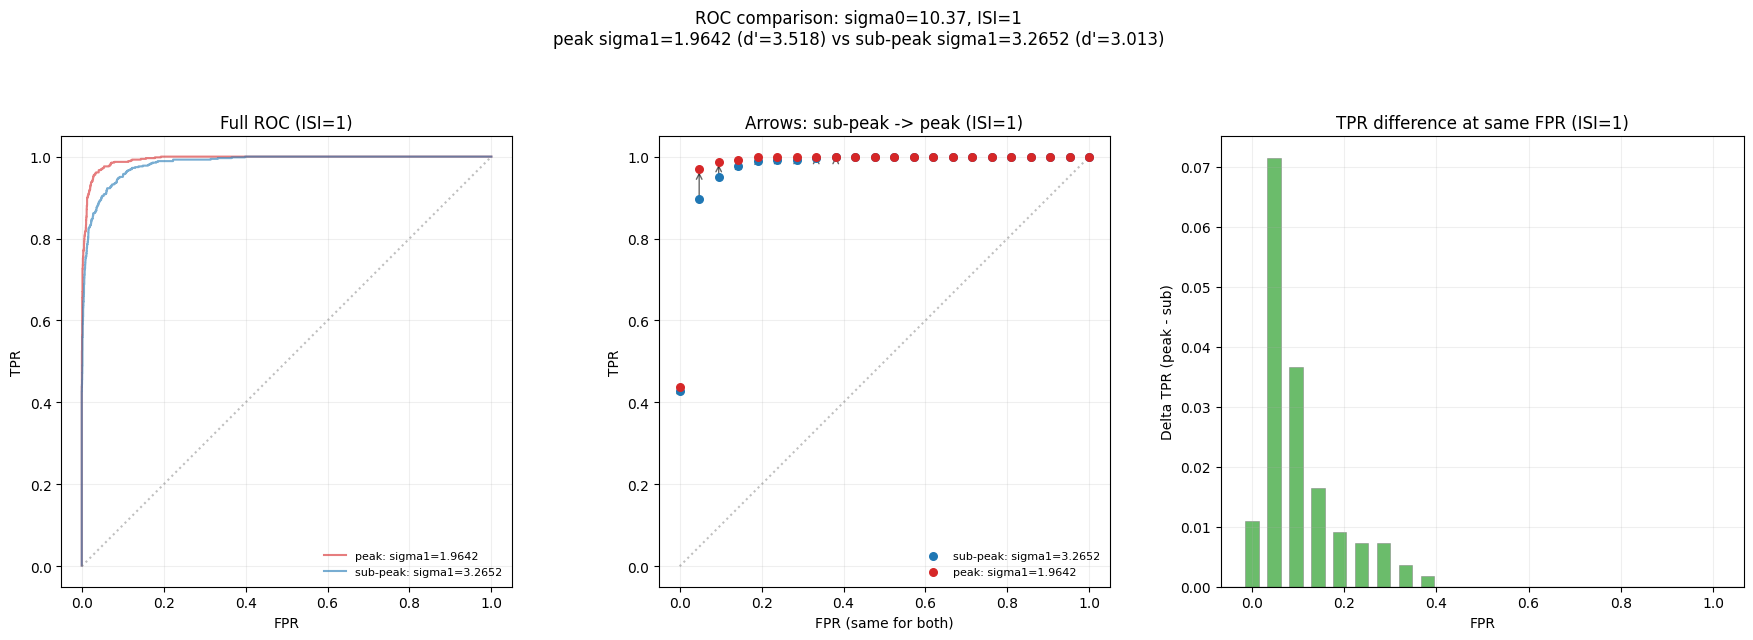

In [59]:
# Sample both ROC curves at the SAME FPR targets for comparison
N_SAMPLE = 20  # enough points to see the shape clearly

fpr_s_peak, tpr_s_peak = sample_roc_at_fpr_targets(fpr_peak, tpr_peak, n_points=N_SAMPLE)
fpr_s_sub, tpr_s_sub = sample_roc_at_fpr_targets(fpr_sub, tpr_sub, n_points=N_SAMPLE)

# Use the same FPR target grid for both, interpolating TPR
common_fpr = np.linspace(0, 1, N_SAMPLE + 2)
tpr_interp_peak = np.interp(common_fpr, fpr_peak, tpr_peak)
tpr_interp_sub = np.interp(common_fpr, fpr_sub, tpr_sub)

# ---- Plot ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# (A) Full ROC curves overlaid
ax = axes[0]
ax.plot(fpr_peak, tpr_peak, '-', color='tab:red', alpha=0.6, lw=1.5,
        label=f'peak: sigma1={sigma1_peak:.4f}')
ax.plot(fpr_sub, tpr_sub, '-', color='tab:blue', alpha=0.6, lw=1.5,
        label=f'sub-peak: sigma1={sigma1_sub:.4f}')
ax.plot([0, 1], [0, 1], ':', color='gray', alpha=0.5)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'Full ROC (ISI={isi_focus})')
ax.legend(fontsize=8, frameon=False)
ax.set_aspect('equal')
ax.grid(alpha=0.2)

# (B) Sampled points with arrows from sub-peak -> peak
ax = axes[1]
ax.plot([0, 1], [0, 1], ':', color='gray', alpha=0.5)

# Plot sampled points
ax.scatter(common_fpr, tpr_interp_sub, s=30, color='tab:blue', zorder=5,
           label=f'sub-peak: sigma1={sigma1_sub:.4f}')
ax.scatter(common_fpr, tpr_interp_peak, s=30, color='tab:red', zorder=5,
           label=f'peak: sigma1={sigma1_peak:.4f}')

# Draw arrows from sub-peak to peak at each FPR
for i in range(len(common_fpr)):
    dy = tpr_interp_peak[i] - tpr_interp_sub[i]
    if abs(dy) > 0.001:  # skip negligible differences
        ax.annotate('', xy=(common_fpr[i], tpr_interp_peak[i]),
                    xytext=(common_fpr[i], tpr_interp_sub[i]),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.0, alpha=0.6))

ax.set_xlabel('FPR (same for both)')
ax.set_ylabel('TPR')
ax.set_title(f'Arrows: sub-peak -> peak (ISI={isi_focus})')
ax.legend(fontsize=8, frameon=False, loc='lower right')
ax.set_aspect('equal')
ax.grid(alpha=0.2)

# (C) Delta TPR (peak - sub) vs FPR
ax = axes[2]
delta_tpr = tpr_interp_peak - tpr_interp_sub
ax.bar(common_fpr, delta_tpr, width=0.03, color=['tab:green' if d >= 0 else 'tab:red' for d in delta_tpr],
       alpha=0.7, edgecolor='gray', linewidth=0.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('FPR')
ax.set_ylabel('Delta TPR (peak - sub)')
ax.set_title(f'TPR difference at same FPR (ISI={isi_focus})')
ax.grid(alpha=0.2)

fig.suptitle(
    f"ROC comparison: sigma0={SIGMA0_FIXED}, ISI={isi_focus}\n"
    f"peak sigma1={sigma1_peak:.4f} (d'={dp_isi1[peak_idx]:.3f}) vs "
    f"sub-peak sigma1={sigma1_sub:.4f} (d'={dp_isi1[sub_peak_idx]:.3f})",
    y=1.06, fontsize=12)
fig.tight_layout()
plt.show()

---
## 8. Score distribution diagnostics

Compare the raw hit and FA score distributions at peak vs sub-peak.
This directly shows whether the bump comes from hits shifting,
FAs shifting, or both.

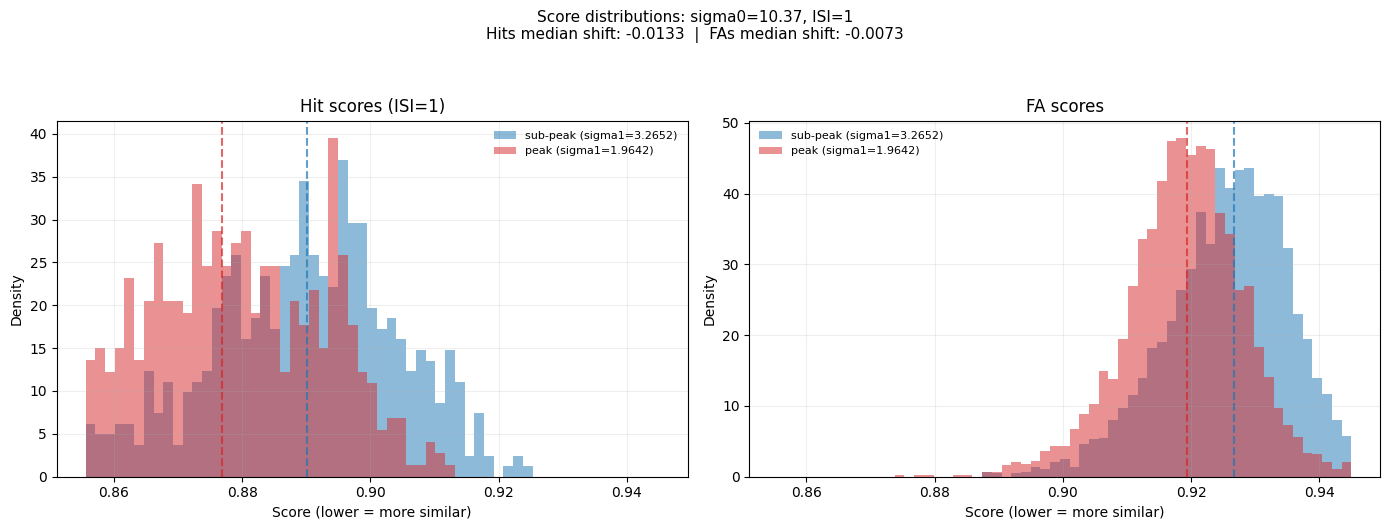

Hit scores: sub-peak median = 0.8901, peak median = 0.8769
FA scores:  sub-peak median = 0.9266, peak median = 0.9193
Hit shift: -0.0133
FA shift:  -0.0073


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Determine common bin range
all_scores = np.concatenate([hits_peak, fas_peak, hits_sub, fas_sub])
bins = np.linspace(np.percentile(all_scores, 1), np.percentile(all_scores, 99), 60)

# (A) Hit score distributions
ax = axes[0]
ax.hist(hits_sub, bins=bins, alpha=0.5, density=True, color='tab:blue',
        label=f'sub-peak (sigma1={sigma1_sub:.4f})')
ax.hist(hits_peak, bins=bins, alpha=0.5, density=True, color='tab:red',
        label=f'peak (sigma1={sigma1_peak:.4f})')
ax.axvline(np.median(hits_sub), ls='--', color='tab:blue', alpha=0.7)
ax.axvline(np.median(hits_peak), ls='--', color='tab:red', alpha=0.7)
ax.set_xlabel('Score (lower = more similar)')
ax.set_ylabel('Density')
ax.set_title(f'Hit scores (ISI={isi_focus})')
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)

# (B) FA score distributions
ax = axes[1]
ax.hist(fas_sub, bins=bins, alpha=0.5, density=True, color='tab:blue',
        label=f'sub-peak (sigma1={sigma1_sub:.4f})')
ax.hist(fas_peak, bins=bins, alpha=0.5, density=True, color='tab:red',
        label=f'peak (sigma1={sigma1_peak:.4f})')
ax.axvline(np.median(fas_sub), ls='--', color='tab:blue', alpha=0.7)
ax.axvline(np.median(fas_peak), ls='--', color='tab:red', alpha=0.7)
ax.set_xlabel('Score (lower = more similar)')
ax.set_ylabel('Density')
ax.set_title(f'FA scores')
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)

fig.suptitle(
    f"Score distributions: sigma0={SIGMA0_FIXED}, ISI={isi_focus}\n"
    f"Hits median shift: {np.median(hits_peak) - np.median(hits_sub):.4f}  |  "
    f"FAs median shift: {np.median(fas_peak) - np.median(fas_sub):.4f}",
    y=1.05, fontsize=11)
fig.tight_layout()
plt.show()

print(f"Hit scores: sub-peak median = {np.median(hits_sub):.4f}, peak median = {np.median(hits_peak):.4f}")
print(f"FA scores:  sub-peak median = {np.median(fas_sub):.4f}, peak median = {np.median(fas_peak):.4f}")
print(f"Hit shift: {np.median(hits_peak) - np.median(hits_sub):.4f}")
print(f"FA shift:  {np.median(fas_peak) - np.median(fas_sub):.4f}")

---
## 9. Quantitative summary

For each ISI, compare the sklearn AUROC and sparse-12 AUROC
at the peak and sub-peak sigma1 values.

In [61]:
print(f"{'ISI':>4s} | {'metric':>12s} | {'sub-peak':>10s} | {'peak':>10s} | {'delta':>10s}")
print("-" * 60)

for isi_val in SIGMA1_ISIS:
    # sklearn
    auc_sk_sub = sklearn_auroc(r_sub["hit_scores_by_isi"][isi_val], r_sub["fa_scores"])
    auc_sk_peak = sklearn_auroc(r_peak["hit_scores_by_isi"][isi_val], r_peak["fa_scores"])
    dp_sk_sub = auc_to_dprime(auc_sk_sub, eps=1e-4)
    dp_sk_peak = auc_to_dprime(auc_sk_peak, eps=1e-4)

    # sparse12
    auc_sp_sub = compute_auroc_sparse12(r_sub["hit_scores_by_isi"][isi_val], r_sub["fa_scores"])
    auc_sp_peak = compute_auroc_sparse12(r_peak["hit_scores_by_isi"][isi_val], r_peak["fa_scores"])
    dp_sp_sub = auc_to_dprime(auc_sp_sub, eps=1e-4)
    dp_sp_peak = auc_to_dprime(auc_sp_peak, eps=1e-4)

    print(f"{isi_val:>4d} | {'sklearn d':>12s}' | {dp_sk_sub:>10.4f} | {dp_sk_peak:>10.4f} | {dp_sk_peak - dp_sk_sub:>+10.4f}")
    print(f"{'':>4s} | {'sparse12 d':>12s}' | {dp_sp_sub:>10.4f} | {dp_sp_peak:>10.4f} | {dp_sp_peak - dp_sp_sub:>+10.4f}")
    print(f"{'':>4s} | {'sklearn AUC':>12s} | {auc_sk_sub:>10.4f} | {auc_sk_peak:>10.4f} | {auc_sk_peak - auc_sk_sub:>+10.4f}")
    print(f"{'':>4s} | {'sparse12 AUC':>12s} | {auc_sp_sub:>10.4f} | {auc_sp_peak:>10.4f} | {auc_sp_peak - auc_sp_sub:>+10.4f}")
    print("-" * 60)

print(f"\nPeak sigma1 = {sigma1_peak:.4f}, Sub-peak sigma1 = {sigma1_sub:.4f}")
print(f"sigma0 = {SIGMA0_FIXED}")

 ISI |       metric |   sub-peak |       peak |      delta
------------------------------------------------------------
   1 |    sklearn d' |     3.0128 |     3.5182 |    +0.5055
     |   sparse12 d' |     2.6406 |     2.8332 |    +0.1926
     |  sklearn AUC |     0.9834 |     0.9936 |    +0.0101
     | sparse12 AUC |     0.9691 |     0.9774 |    +0.0084
------------------------------------------------------------
   2 |    sklearn d' |     1.9906 |     2.8719 |    +0.8813
     |   sparse12 d' |     1.9258 |     2.5775 |    +0.6517
     |  sklearn AUC |     0.9204 |     0.9789 |    +0.0585
     | sparse12 AUC |     0.9134 |     0.9658 |    +0.0525
------------------------------------------------------------
   4 |    sklearn d' |     1.3322 |     2.4201 |    +1.0879
     |   sparse12 d' |     1.3152 |     2.2838 |    +0.9687
     |  sklearn AUC |     0.8269 |     0.9565 |    +0.1296
     | sparse12 AUC |     0.8238 |     0.9468 |    +0.1230
--------------------------------------------

---
## 10. Alternative ROC diagnostics: fix TPR and fix threshold

The section above fixed FPR and compared TPR. Here we do two complementary checks:

1. **Fix TPR** and compare how FPR changes.
2. **Fix threshold** and compare both TPR and FPR on the same decision criterion.


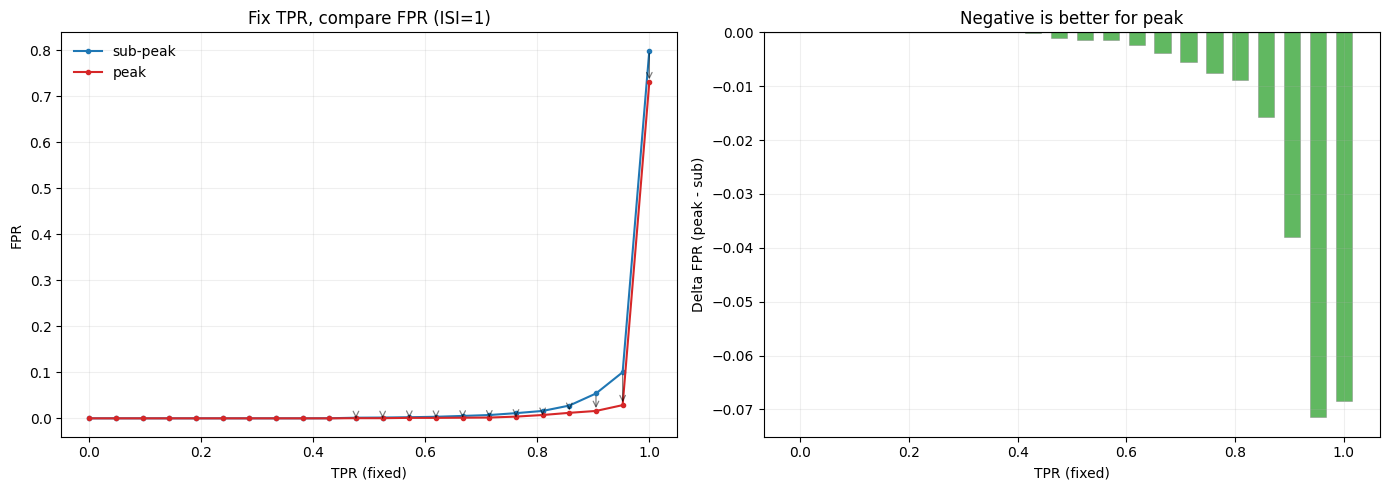

Fix-TPR summary (negative delta FPR means peak ROC is better):
  median delta FPR = -0.0012
  min/max delta FPR = -0.0715 / +0.0000


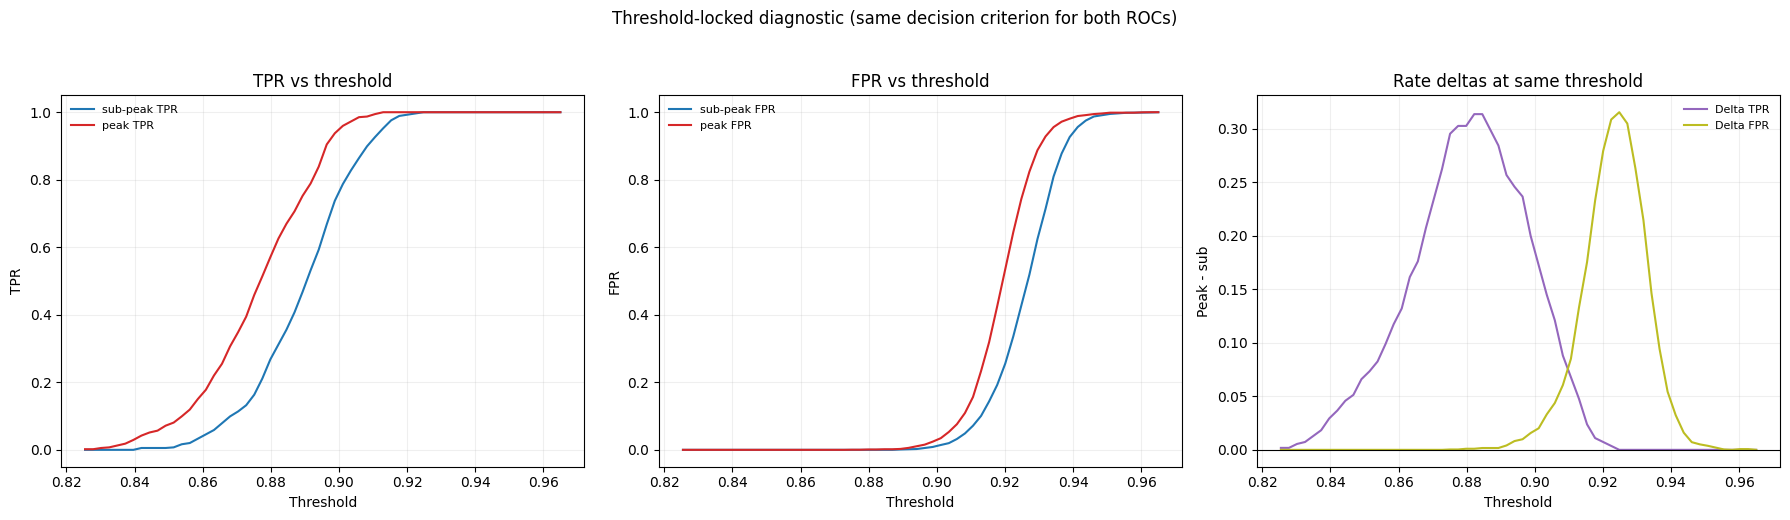

In [62]:
def sample_roc_at_tpr_targets(fpr, tpr, n_points=20):
    """Sample ROC at common TPR targets and return interpolated FPR."""
    common_tpr = np.linspace(0, 1, n_points + 2)
    # invert monotonic mapping via interpolation on sorted-by-TPR arrays
    order = np.argsort(tpr)
    tpr_sorted = tpr[order]
    fpr_sorted = fpr[order]
    # unique TPRs avoid issues with repeated values
    tpr_u, idx_u = np.unique(tpr_sorted, return_index=True)
    fpr_u = fpr_sorted[idx_u]
    fpr_interp = np.interp(common_tpr, tpr_u, fpr_u)
    return common_tpr, fpr_interp


# ---- A) Fix TPR, compare FPR ----
common_tpr, fpr_at_tpr_peak = sample_roc_at_tpr_targets(fpr_peak, tpr_peak, n_points=20)
_, fpr_at_tpr_sub = sample_roc_at_tpr_targets(fpr_sub, tpr_sub, n_points=20)

delta_fpr = fpr_at_tpr_peak - fpr_at_tpr_sub

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(common_tpr, fpr_at_tpr_sub, 'o-', ms=3, color='tab:blue', label='sub-peak')
ax.plot(common_tpr, fpr_at_tpr_peak, 'o-', ms=3, color='tab:red', label='peak')
for i in range(len(common_tpr)):
    if abs(delta_fpr[i]) > 1e-3:
        ax.annotate('', xy=(common_tpr[i], fpr_at_tpr_peak[i]),
                    xytext=(common_tpr[i], fpr_at_tpr_sub[i]),
                    arrowprops=dict(arrowstyle='->', lw=0.9, alpha=0.5, color='black'))
ax.set_xlabel('TPR (fixed)')
ax.set_ylabel('FPR')
ax.set_title(f'Fix TPR, compare FPR (ISI={isi_focus})')
ax.grid(alpha=0.2)
ax.legend(frameon=False)

ax = axes[1]
ax.bar(common_tpr, delta_fpr, width=0.03,
       color=['tab:green' if v <= 0 else 'tab:red' for v in delta_fpr],
       alpha=0.75, edgecolor='gray', linewidth=0.4)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('TPR (fixed)')
ax.set_ylabel('Delta FPR (peak - sub)')
ax.set_title('Negative is better for peak')
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

print('Fix-TPR summary (negative delta FPR means peak ROC is better):')
print(f'  median delta FPR = {np.median(delta_fpr):+.4f}')
print(f'  min/max delta FPR = {np.min(delta_fpr):+.4f} / {np.max(delta_fpr):+.4f}')


# ---- B) Fix threshold, compare both TPR and FPR ----
common_thr = np.linspace(np.min(all_scores), np.max(all_scores), 60)

def rates_at_thresholds(hits, fas, thresholds):
    hits = np.asarray(hits)
    fas = np.asarray(fas)
    tpr = np.array([(hits <= t).mean() for t in thresholds])
    fpr = np.array([(fas <= t).mean() for t in thresholds])
    return tpr, fpr

tpr_thr_peak, fpr_thr_peak = rates_at_thresholds(hits_peak, fas_peak, common_thr)
tpr_thr_sub, fpr_thr_sub = rates_at_thresholds(hits_sub, fas_sub, common_thr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(common_thr, tpr_thr_sub, color='tab:blue', label='sub-peak TPR')
ax.plot(common_thr, tpr_thr_peak, color='tab:red', label='peak TPR')
ax.set_xlabel('Threshold')
ax.set_ylabel('TPR')
ax.set_title('TPR vs threshold')
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
ax.plot(common_thr, fpr_thr_sub, color='tab:blue', label='sub-peak FPR')
ax.plot(common_thr, fpr_thr_peak, color='tab:red', label='peak FPR')
ax.set_xlabel('Threshold')
ax.set_ylabel('FPR')
ax.set_title('FPR vs threshold')
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=8)

ax = axes[2]
ax.plot(common_thr, tpr_thr_peak - tpr_thr_sub, color='tab:purple', label='Delta TPR')
ax.plot(common_thr, fpr_thr_peak - fpr_thr_sub, color='tab:olive', label='Delta FPR')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Threshold')
ax.set_ylabel('Peak - sub')
ax.set_title('Rate deltas at same threshold')
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=8)

fig.suptitle('Threshold-locked diagnostic (same decision criterion for both ROCs)', y=1.03)
fig.tight_layout()
plt.show()


---
## 11. Full sigma1 sweep for sigma0=10, ISI=1

This re-runs a dedicated sweep with your requested settings:
- `sigma0 = 10`
- `sigma1 in [0.8, 15]`

It computes AUROC and d' for all sigma1 values and then builds an animation showing:
1. d' vs sigma1 with a moving marker
2. hit-score distribution (ISI=1)
3. FA-score distribution

All distribution panels share fixed x/y scales across frames.


Sweep done: 15 sigma1 values
Best d' @ sigma1=1.4993: d'=3.8861, AUC=0.9970


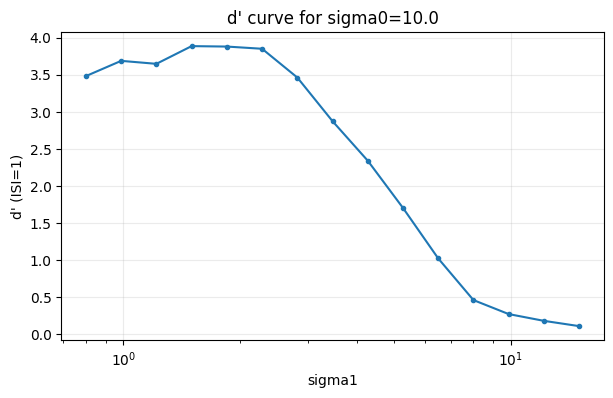

In [23]:
from matplotlib.animation import FuncAnimation, PillowWriter

SIGMA0_SWEEP = 10.0
SIGMA1_SWEEP = np.exp(np.linspace(np.log(0.8), np.log(15.0), 15))
ISI_SWEEP = 1
N_MC_SWEEP = N_MC  # set lower/higher depending on speed vs stability

sweep_results = []
for gi, sigma1_val in enumerate(SIGMA1_SWEEP):
    all_hits_isi1 = []
    all_fas = []

    for rep in range(N_MC_SWEEP):
        for si, seq in enumerate(sigma1_exps):
            t_isis = seq_trial_isis[si]
            run_out = run_experiment_scores(
                sigma0=SIGMA0_SWEEP,
                sigma1=float(sigma1_val),
                sigma2=sigma2_init,
                t_step=t_step,
                rate=0,
                noise_mode=noise_mode,
                metric=metric,
                X0=X,
                name_to_idx=name_to_idx,
                experiment_list=[seq],
                debug=False,
                seed=9_100_000 + gi * 100_000 + rep * 1000 + si,
            )
            h = np.asarray(run_out['hits'])
            fa = np.asarray(run_out['fas'])
            all_fas.extend(fa.tolist())

            # ISI filter (same logic as earlier in notebook)
            mask_isi1 = np.asarray(t_isis) == ISI_SWEEP
            all_hits_isi1.extend(h[mask_isi1].tolist())

    auc = sklearn_auroc(all_hits_isi1, all_fas)
    dp = auc_to_dprime(auc, eps=1e-4)
    sweep_results.append(dict(
        sigma1=float(sigma1_val),
        auc=float(auc),
        dprime=float(dp),
        hits=np.asarray(all_hits_isi1, dtype=float),
        fas=np.asarray(all_fas, dtype=float),
    ))

sigma1_sweep_vals = np.array([r['sigma1'] for r in sweep_results])
auc_sweep_vals = np.array([r['auc'] for r in sweep_results])
dp_sweep_vals = np.array([r['dprime'] for r in sweep_results])

best_idx = int(np.argmax(dp_sweep_vals))
print(f"Sweep done: {len(sweep_results)} sigma1 values")
print(f"Best d' @ sigma1={sigma1_sweep_vals[best_idx]:.4f}: d'={dp_sweep_vals[best_idx]:.4f}, AUC={auc_sweep_vals[best_idx]:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(sigma1_sweep_vals, dp_sweep_vals, '-o', ms=3)
ax.set_xscale('log')
ax.set_xlabel('sigma1')
ax.set_ylabel("d' (ISI=1)")
ax.set_title(f"d' curve for sigma0={SIGMA0_SWEEP}")
ax.grid(alpha=0.25)
plt.show()


Saved animation: artifacts/sigma1_sweep_dprime_and_distributions.gif


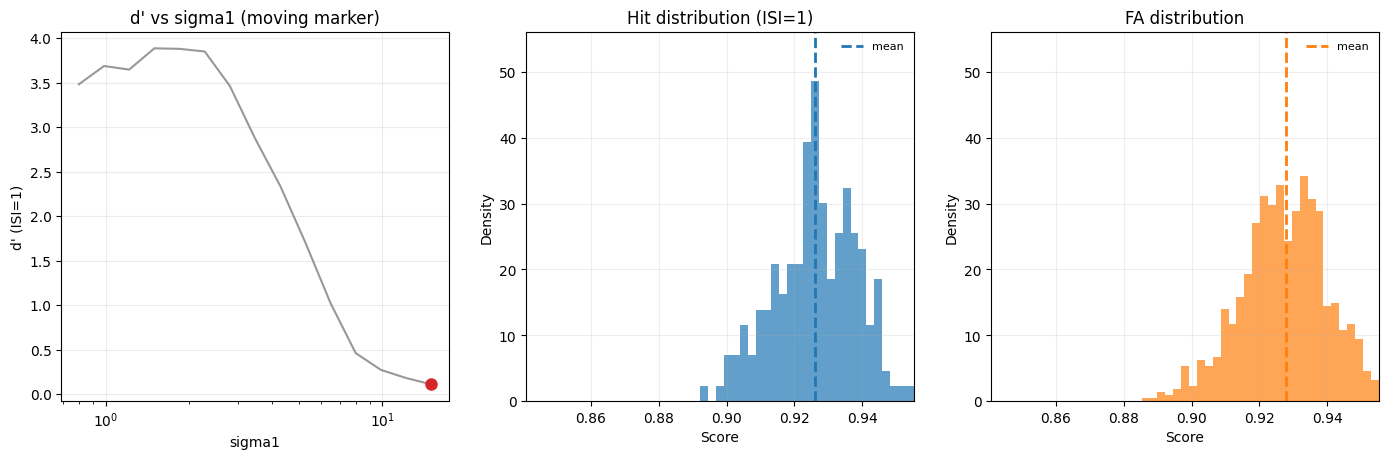

In [54]:
# Prepare fixed scales for animation
all_hits_concat = np.concatenate([r['hits'] for r in sweep_results])
all_fas_concat = np.concatenate([r['fas'] for r in sweep_results])
all_concat = np.concatenate([all_hits_concat, all_fas_concat])

x_lo = np.percentile(all_concat, 0.5)
x_hi = np.percentile(all_concat, 99.5)
bins = np.linspace(x_lo, x_hi, 50)

# Use global density limits for consistent y-scale
max_density = 0.0
for r in sweep_results:
    h_hist, _ = np.histogram(r['hits'], bins=bins, density=True)
    f_hist, _ = np.histogram(r['fas'], bins=bins, density=True)
    max_density = max(max_density, h_hist.max() if len(h_hist) else 0.0, f_hist.max() if len(f_hist) else 0.0)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
ax_curve, ax_hits, ax_fas = axes

# Static d' curve
ax_curve.plot(sigma1_sweep_vals, dp_sweep_vals, '-', color='tab:gray', alpha=0.8)
ax_curve.set_xscale('log')
ax_curve.set_xlabel('sigma1')
ax_curve.set_ylabel("d' (ISI=1)")
ax_curve.set_title("d' vs sigma1 (moving marker)")
ax_curve.grid(alpha=0.25)
marker, = ax_curve.plot([sigma1_sweep_vals[0]], [dp_sweep_vals[0]], 'o', color='tab:red', ms=8)


def draw_distributions(idx):
    r = sweep_results[idx]
    for ax in (ax_hits, ax_fas):
        ax.cla()

    ax_hits.hist(r['hits'], bins=bins, density=True, alpha=0.7, color='tab:blue')
    ax_hits.axvline(np.mean(r['hits']), color='tab:blue', ls='--', lw=2, label='mean')
    ax_hits.set_xlim(x_lo, x_hi)
    ax_hits.set_ylim(0, max_density * 1.1)
    ax_hits.set_xlabel('Score')
    ax_hits.set_ylabel('Density')
    ax_hits.set_title('Hit distribution (ISI=1)')
    ax_hits.grid(alpha=0.2)
    ax_hits.legend(frameon=False, fontsize=8)

    ax_fas.hist(r['fas'], bins=bins, density=True, alpha=0.7, color='tab:orange')
    ax_fas.axvline(np.mean(r['fas']), color='tab:orange', ls='--', lw=2, label='mean')
    ax_fas.set_xlim(x_lo, x_hi)
    ax_fas.set_ylim(0, max_density * 1.1)
    ax_fas.set_xlabel('Score')
    ax_fas.set_ylabel('Density')
    ax_fas.set_title('FA distribution')
    ax_fas.grid(alpha=0.2)
    ax_fas.legend(frameon=False, fontsize=8)


def update(frame_idx):
    marker.set_data([sigma1_sweep_vals[frame_idx]], [dp_sweep_vals[frame_idx]])
    draw_distributions(frame_idx)
    # fig.suptitle(
    #     f"sigma0={SIGMA0_SWEEP:.1f} | frame {frame_idx+1}/{len(sweep_results)} | "
    #     f"sigma1={sigma1_sweep_vals[frame_idx]:.3f} | d'={dp_sweep_vals[frame_idx]:.3f} | "
    #     f"AUC={auc_sweep_vals[frame_idx]:.3f}",
    #     y=1.02,
    # )
    return (marker,)


ani = FuncAnimation(fig, update, frames=len(sweep_results), interval=350, blit=False)

out_dir = Path('artifacts')
out_dir.mkdir(parents=True, exist_ok=True)
gif_path = out_dir / 'sigma1_sweep_dprime_and_distributions.gif'

try:
    ani.save(gif_path, writer=PillowWriter(fps=3))
    print(f'Saved animation: {gif_path}')
except Exception as e:
    print('Could not save GIF (likely missing Pillow writer in environment):', repr(e))

plt.show()
